# Data Storytelling Project Notebook

Brandon Kung 

Things to do:
- Redo the extraction of the data so you filter out non-kinetic missions, those with missing geographic coordinates, and those that INTERSECT with the Laotian border
- Revise the comments
- Fix the fact that we don't have SHDI for LA-XS
- Remove duplicate observations

Hard Choices I made:
- Chose to include observations with missing/nonsensical data in certain rows (such as 0 weapon type weight but positive number of weapons dropped, etc.

In [45]:
#pip install rasterio

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 44.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 2/3 [rasterio]  WARNING: The script rio is installed in '/users/bkung/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [rasterio]
Note: you may need to restart the kernel to use updated packages.


In [35]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# Loading in the Subnational HDI Dataset and Exploration 

In [2]:
shdi_df = pd.read_csv('../data/GDL-Subnational-HDI-data.csv')

In [27]:
shdi_df.head()

,Country,Continent,ISO_Code,Level,GDLCODE,Region,1990,1991,1992,1993,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Cambodia,Asia/Pacific,KHM,National,KHMt,Total,0.387,0.392,0.396,0.399,...,0.557,0.562,0.570,0.578,0.586,0.593,0.595,0.594,0.602,0.606
1,Cambodia,Asia/Pacific,KHM,Subnat,KHMr101,Banteay Mean Chey,0.372,0.377,0.380,0.383,...,0.564,0.573,0.586,0.598,0.610,0.621,0.626,0.630,0.638,0.642
2,Cambodia,Asia/Pacific,KHM,Subnat,KHMr113,Bat Dambang-Krong Pailin,0.396,0.401,0.405,0.407,...,0.581,0.582,0.586,0.590,0.593,0.596,0.594,0.589,0.596,0.600
3,Cambodia,Asia/Pacific,KHM,Subnat,KHMr102,Kampong Cham (incl Tboung Khmum),0.372,0.376,0.380,0.382,...,0.535,0.536,0.540,0.543,0.546,0.548,0.545,0.540,0.547,0.551
4,Cambodia,Asia/Pacific,KHM,Subnat,KHMr103,Kampong Chhnang,0.351,0.355,0.359,0.361,...,0.541,0.551,0.563,0.576,0.588,0.599,0.605,0.609,0.617,0.621


In [ ]:
shdi_df.info()

The Lao data has more subnational units and it was bombed more, so we will focus on Lao.

In [3]:
# filtering dataset to include only Laotian provinces
lao_shdi = shdi_df[(shdi_df['ISO_Code'] == 'LAO') & (shdi_df['Level'] != 'National')]
lao_shdi['Level'].value_counts()

Level
Subnat    17
Name: count, dtype: int64

In [4]:
id_cols = ['Country', 'Continent', 'ISO_Code', 'Level', 'GDLCODE', 'Region']

lao_shdi_df = pd.melt(
    lao_shdi,
    id_vars=id_cols,
    var_name='year',
    value_name='shdi_value'  
)

In [28]:
print(lao_shdi_df.columns)

Index(['Country', 'Continent', 'ISO_Code', 'Level', 'GDLCODE', 'Region',
       'year', 'shdi_value'],
      dtype='object')


In [5]:
# filtering to the columns we want
lao_shdi_df = lao_shdi_df[['ISO_Code', 'Region', 'year', 'shdi_value']]

In [ ]:
lao_shdi_df.head(23)

It seems like the ISO Code is not mapped by subnational divisions, so let's fix that.

In [6]:
ISO_dict = {'Attapeu': 'LA-AT', 'Bokeo': 'LA-BK', 'Borikhamxay': 'LA-BL', 'Champasack': 'LA-CH', 
            'Huaphanh': 'LA-HO', 'Khammuane': 'LA-KH', 'Luangnamtha': 'LA-LM', 'Luangprabang': 'LA-LP', 'Oudomxay': 'LA-OU', 'Phongsaly': 'LA-PH', 
            'Saravane': 'LA-SL', 'Savannakhet': 'LA-SV', 'Sayabury': 'LA-XA', 'Sekong': 'LA-XE', 'Vientiane Municipality': 'LA-VT', 
           'Vientiane Province': 'LA-VI', 'Xiengkhuang': 'LA-XI'}

# Add the new column
lao_shdi_df['ISO_Code'] = lao_shdi_df['Region'].map(ISO_dict)
lao_shdi_df['ISO_Code'].head(17)

0     LA-AT
1     LA-BK
2     LA-BL
3     LA-CH
4     LA-HO
5     LA-KH
6     LA-LM
7     LA-LP
8     LA-OU
9     LA-PH
10    LA-SL
11    LA-SV
12    LA-XA
13    LA-XE
14    LA-VT
15    LA-VI
16    LA-XI
Name: ISO_Code, dtype: object

In [ ]:
# Graphing line trend for exploration purposes
plt.figure(figsize=(20, 6))

for key, grp in lao_shdi_df.groupby(['GDLCODE']):
    plt.plot(grp['year'], grp['shdi_value'], alpha=0.05, color='blue')

plt.title('Trajectories of Subnational HDI Over Time')
plt.xlabel('Year')
plt.ylabel('Subnational HDI Score')

# Loading in the THOR Bombing Dataset

In [ ]:
# import polars as pl

In [ ]:
# using polars to filter the data because it's very large 
#columns_to_keep = [
    #'TGTCOUNTRY',
    #'TGTLATDD_DDD_WGS84',
    #'TGTLONDDD_DDD_WGS84',
    #'MSNDATE',
    #'WEAPONTYPEWEIGHT',
    #'NUMWEAPONSDELIVERED',
    #'MFUNC_DESC_CLASS',
    #'WEAPONTYPECLASS',
    #'WEAPONTYPE'
#]

#(
    #pl.scan_csv('../data/large_thor_file.csv', ignore_errors=True)
    #.select(columns_to_keep)
    #.filter(pl.col('TGTCOUNTRY').str.to_uppercase() == 'LAOS')
    #.collect()
    #.write_csv('laos_bombing_clean.csv')
#)

In [7]:
laos_df = pd.read_csv('../data/laos_bombing_clean.csv')

In [5]:
print(laos_df['MFUNC_DESC_CLASS'].value_counts())

MFUNC_DESC_CLASS
KINETIC       946142
NONKINETIC    323705
Name: count, dtype: int64


In [8]:
laos_df_clean = laos_df[laos_df['MFUNC_DESC_CLASS'].isin(['KINETIC'])]

In [9]:
laos_df_clean = laos_df_clean.dropna(subset=['TGTLATDD_DDD_WGS84', 'TGTLONDDD_DDD_WGS84'])

# Integrating Level 1 Boundaries (Provinces)

In [10]:
# Loading the administrative boundaries
gdf_provinces = gpd.read_file('../data/LaosBoundaryLvl1.json')
print(gdf_provinces.head())
gdf_provinces.columns

     GID_1 GID_0 COUNTRY       NAME_1                         VARNAME_1  \
0  LAO.1_1   LAO    Laos       Attapu  Attopu|Atpu|Attapeu|Attopeu|Muan   
1  LAO.2_1   LAO    Laos        Bokeo                                NA   
2  LAO.3_1   LAO    Laos  Bolikhamxai  Bolikhamsai|Bolikhamxay|Borikham   
3  LAO.4_1   LAO    Laos    Champasak  Bassac|Champassack|Champassak|Ch   
4  LAO.5_1   LAO    Laos     Houaphan     HuaPhan|Huaphanh|SamNeua|XamN   

  NL_NAME_1   TYPE_1 ENGTYPE_1 CC_1 HASC_1  ISO_1  \
0        NA  Khoueng  Province   NA  LA.AT  LA-AT   
1        NA  Khoueng  Province   NA  LA.BK  LA-BK   
2        NA  Khoueng  Province   NA  LA.BL  LA-BL   
3        NA  Khoueng  Province   NA  LA.CH  LA-CH   
4        NA  Khoueng  Province   NA  LA.HO     NA   

                                            geometry  
0  MULTIPOLYGON (((107.1091 14.394, 107.1061 14.3...  
1  MULTIPOLYGON (((100.7467 19.962, 100.7339 19.9...  
2  MULTIPOLYGON (((104.0322 18.8128, 104.0392 18....  
3  MULTIPO

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')

No ISO code for certain provinces. Let's fix that.

In [11]:
# Mapping ISO codes 
ISO_dict_2 = {'Attapu': 'LA-AT', 'Bokeo': 'LA-BK', 'Bolikhamxai': 'LA-BL', 'Champasak': 'LA-CH', 
            'Houaphan': 'LA-HO', 'Khammouan': 'LA-KH', 'LouangNamtha': 'LA-LM', 'Louangphrabang': 'LA-LP', 'Oudômxai': 'LA-OU', 'Phôngsali': 'LA-PH', 
            'Saravan': 'LA-SL', 'Savannakhét': 'LA-SV', 'Xaignabouri': 'LA-XA', 'Xékong': 'LA-XE', 'Vientiane[prefecture]': 'LA-VT', 
           'Vientiane': 'LA-VI', 'Xaisômboun': 'LA-XS', 'Xiangkhoang': 'LA-XI'}

# Add the new column
gdf_provinces['ISO_1'] = gdf_provinces['NAME_1'].map(ISO_dict_2)
gdf_provinces['ISO_1'].head(17)

0     LA-AT
1     LA-BK
2     LA-BL
3     LA-CH
4     LA-HO
5     LA-KH
6     LA-LM
7     LA-LP
8     LA-OU
9     LA-PH
10    LA-SL
11    LA-SV
12    LA-VI
13    LA-VT
14    LA-XA
15    LA-XS
16    LA-XE
Name: ISO_1, dtype: object

In [12]:
# Getting rid of useless columns
gdf_provinces = gdf_provinces[['GID_1', 'NAME_1', 'VARNAME_1', 'ENGTYPE_1', 'ISO_1', 'geometry']]
gdf_provinces

,GID_1,NAME_1,VARNAME_1,ENGTYPE_1,ISO_1,geometry
0,LAO.1_1,Attapu,Attopu|Atpu|Attapeu|Attopeu|Muan,Province,LA-AT,"MULTIPOLYGON (((107.1091 14.394, 107.1061 14.3..."
1,LAO.2_1,Bokeo,NA,Province,LA-BK,"MULTIPOLYGON (((100.7467 19.962, 100.7339 19.9..."
2,LAO.3_1,Bolikhamxai,Bolikhamsai|Bolikhamxay|Borikham,Province,LA-BL,"MULTIPOLYGON (((104.0322 18.8128, 104.0392 18...."
3,LAO.4_1,Champasak,Bassac|Champassack|Champassak|Ch,Province,LA-CH,"MULTIPOLYGON (((105.7842 14.0456, 105.785 14.0..."
4,LAO.5_1,Houaphan,HuaPhan|Huaphanh|SamNeua|XamN,Province,LA-HO,"MULTIPOLYGON (((104.0044 20.9067, 104.021 20.9..."
5,LAO.6_1,Khammouan,Khammouane|Khammuan,Province,LA-KH,"MULTIPOLYGON (((105.7024 17.1156, 105.6997 17...."
6,LAO.7_1,LouangNamtha,Haut-Mekong|Luangnamtha|MuongLu,Province,LA-LM,"MULTIPOLYGON (((101.2223 20.3108, 101.2103 20...."
7,LAO.8_1,Louangphrabang,LoangPrabang|Louangphabang|Loua,Province,LA-LP,"MULTIPOLYGON (((102.3773 19.3819, 102.373 19.3..."
8,LAO.9_1,Oudômxai,Oudomsai|Oudomsay|Oudomxay|UdomX,Province,LA-OU,"MULTIPOLYGON (((102.1481 20.0885, 102.1318 20...."
9,LAO.10_1,Phôngsali,FongSali|Phongsaly,Province,LA-PH,"MULTIPOLYGON (((102.624 20.9541, 102.5995 20.9..."


In [ ]:
# Setting up the plotting canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plotting the GeoDataFrame
gdf_provinces.plot(
    ax=ax, 
    facecolor='whitesmoke', 
    edgecolor='black', 
    linewidth=0.8
)

# Formatting the map
plt.title('Laos Administrative Boundaries', fontsize=16, pad=20)
ax.axis('off')

# 6. Render the plot
plt.tight_layout()
plt.show()

# Using the provinces to clean the bombing dataset further

In [48]:
# Convert the pandas DataFrame into a GeoDataFrame of points
# WGS84 (EPSG:4326) is the standard CRS for latitude/longitude coordinates
bombing_gdf = gpd.GeoDataFrame(
    laos_df_clean, 
    geometry=gpd.points_from_xy(laos_df_clean['TGTLONDDD_DDD_WGS84'], laos_df_clean['TGTLATDD_DDD_WGS84']),
    crs="EPSG:4326"
)

In [49]:
# 3. Align CRS
if bombing_gdf.crs != gdf_provinces.crs:
    gdf_provinces = gdf_provinces.to_crs(bombing_gdf.crs)

In [56]:
print(f"Original point count: {len(bombing_gdf):,}")

# 3. Perform the Spatial Clip
# This immediately drops any point (like 0.0, 0.0 or bombs dropped over the border) 
# that does not intersect with the Laos multipolygon.
gdf_points_clipped = gpd.clip(bombing_gdf, gdf_provinces)

print(f"Cleaned point count: {len(gdf_points_clipped):,}")
print(f"Dropped {len(bombing_gdf) - len(gdf_points_clipped):,} stray points.")

# 4. Permanently save the strict dataset
# We drop the geopandas 'geometry' column to save it cleanly back to a standard Pandas CSV
df_clean_strict = pd.DataFrame(gdf_points_clipped.drop(columns=['geometry']))
df_clean_strict.to_csv('../data/laos_bombing_clean_strict.csv', index=False)

Original point count: 900,309
Cleaned point count: 861,994
Dropped 38,315 stray points.


In [58]:
laos_strikes_gdf = gpd.GeoDataFrame(
    df_clean_strict, 
    geometry=gpd.points_from_xy(df_clean_strict['TGTLONDDD_DDD_WGS84'], df_clean_strict['TGTLATDD_DDD_WGS84']),
    crs="EPSG:4326"
)

# Merging the datasets

In [25]:
# Merging the HDI and administrative boundaries 
gdf_provinces.rename(columns={'ISO_1': 'ISO_Code'}, inplace=True)
shdi_lvl1_merge = pd.merge(gdf_provinces, lao_shdi_df, on='ISO_Code', how='left')
frequencies = shdi_lvl1_merge['ISO_Code'].value_counts()
print(frequencies)

ISO_Code
LA-AT    34
LA-BK    34
LA-BL    34
LA-CH    34
LA-HO    34
LA-KH    34
LA-LM    34
LA-LP    34
LA-OU    34
LA-PH    34
LA-SL    34
LA-SV    34
LA-VI    34
LA-VT    34
LA-XA    34
LA-XE    34
LA-XI    34
LA-XS     1
Name: count, dtype: int64


In [28]:
# 4. Perform the Spatial Join
# 'predicate="within"' ensures we find which province polygon each point sits inside
# 'how="left"' keeps all points and appends the province columns to them
points_with_provinces = gpd.sjoin(bombing_gdf, gdf_provinces, how='left', predicate='within')

In [31]:
# 5. Group by Province and Aggregate the Impact
# Replace 'NAME_1' with the actual column name for province names in your shapefile
spatial_summary = points_with_provinces.groupby('NAME_1').agg(
    total_missions=('TGTCOUNTRY', 'size'),
    total_tonnage=('WEAPONTYPEWEIGHT', 'sum')
).reset_index()

# View the result
print(spatial_summary.head())

        NAME_1  total_missions  total_tonnage
0       Attapu           58285       15277756
1        Bokeo             217          19339
2  Bolikhamxai            6659        2067976
3    Champasak           12983        1196153
4     Houaphan           21609        7507176


In [32]:
# Merge the aggregated statistics back to the geometry data
bombing_admin_df = gdf_provinces.merge(spatial_summary, on='NAME_1', how='left')

In [33]:
# Fill provinces that had zero bombing missions with 0 instead of NaN
bombing_admin_df['total_tonnage'] = bombing_admin_df['total_tonnage'].fillna(0)
bombing_admin_df['total_missions'] = bombing_admin_df['total_missions'].fillna(0)

In [37]:
bombing_admin_df.head(20)

,GID_1,NAME_1,VARNAME_1,ENGTYPE_1,ISO_Code,geometry,total_missions,total_tonnage
0,LAO.1_1,Attapu,Attopu|Atpu|Attapeu|Attopeu|Muan,Province,LA-AT,"MULTIPOLYGON (((107.1091 14.394, 107.1061 14.3...",58285,15277756
1,LAO.2_1,Bokeo,NA,Province,LA-BK,"MULTIPOLYGON (((100.7467 19.962, 100.7339 19.9...",217,19339
2,LAO.3_1,Bolikhamxai,Bolikhamsai|Bolikhamxay|Borikham,Province,LA-BL,"MULTIPOLYGON (((104.0322 18.8128, 104.0392 18....",6659,2067976
3,LAO.4_1,Champasak,Bassac|Champassack|Champassak|Ch,Province,LA-CH,"MULTIPOLYGON (((105.7842 14.0456, 105.785 14.0...",12983,1196153
4,LAO.5_1,Houaphan,HuaPhan|Huaphanh|SamNeua|XamN,Province,LA-HO,"MULTIPOLYGON (((104.0044 20.9067, 104.021 20.9...",21609,7507176
5,LAO.6_1,Khammouan,Khammouane|Khammuan,Province,LA-KH,"MULTIPOLYGON (((105.7024 17.1156, 105.6997 17....",194686,62508725
6,LAO.7_1,LouangNamtha,Haut-Mekong|Luangnamtha|MuongLu,Province,LA-LM,"MULTIPOLYGON (((101.2223 20.3108, 101.2103 20....",44,9258
7,LAO.8_1,Louangphrabang,LoangPrabang|Louangphabang|Loua,Province,LA-LP,"MULTIPOLYGON (((102.3773 19.3819, 102.373 19.3...",11010,1787840
8,LAO.9_1,Oudômxai,Oudomsai|Oudomsay|Oudomxay|UdomX,Province,LA-OU,"MULTIPOLYGON (((102.1481 20.0885, 102.1318 20....",1027,311833
9,LAO.10_1,Phôngsali,FongSali|Phongsaly,Province,LA-PH,"MULTIPOLYGON (((102.624 20.9541, 102.5995 20.9...",3017,942637


# Mapping SHDI and Bombing

In [12]:
# Filtering to the latest year (2023)
shdi_df_2023 = shdi_lvl1_merge[shdi_lvl1_merge['year'] == '2023']
shdi_df_2023.head(20)

,GID_1,NAME_1,VARNAME_1,ENGTYPE_1,ISO_Code,geometry,Region,year,shdi_value
33,LAO.1_1,Attapu,Attopu|Atpu|Attapeu|Attopeu|Muan,Province,LA-AT,"MULTIPOLYGON (((107.1091 14.394, 107.1061 14.3...",Attapeu,2023,0.593
67,LAO.2_1,Bokeo,NA,Province,LA-BK,"MULTIPOLYGON (((100.7467 19.962, 100.7339 19.9...",Bokeo,2023,0.589
101,LAO.3_1,Bolikhamxai,Bolikhamsai|Bolikhamxay|Borikham,Province,LA-BL,"MULTIPOLYGON (((104.0322 18.8128, 104.0392 18....",Borikhamxay,2023,0.653
135,LAO.4_1,Champasak,Bassac|Champassack|Champassak|Ch,Province,LA-CH,"MULTIPOLYGON (((105.7842 14.0456, 105.785 14.0...",Champasack,2023,0.609
169,LAO.5_1,Houaphan,HuaPhan|Huaphanh|SamNeua|XamN,Province,LA-HO,"MULTIPOLYGON (((104.0044 20.9067, 104.021 20.9...",Huaphanh,2023,0.588
203,LAO.6_1,Khammouan,Khammouane|Khammuan,Province,LA-KH,"MULTIPOLYGON (((105.7024 17.1156, 105.6997 17....",Khammuane,2023,0.598
237,LAO.7_1,LouangNamtha,Haut-Mekong|Luangnamtha|MuongLu,Province,LA-LM,"MULTIPOLYGON (((101.2223 20.3108, 101.2103 20....",Luangnamtha,2023,0.583
271,LAO.8_1,Louangphrabang,LoangPrabang|Louangphabang|Loua,Province,LA-LP,"MULTIPOLYGON (((102.3773 19.3819, 102.373 19.3...",Luangprabang,2023,0.601
305,LAO.9_1,Oudômxai,Oudomsai|Oudomsay|Oudomxay|UdomX,Province,LA-OU,"MULTIPOLYGON (((102.1481 20.0885, 102.1318 20....",Oudomxay,2023,0.577
339,LAO.10_1,Phôngsali,FongSali|Phongsaly,Province,LA-PH,"MULTIPOLYGON (((102.624 20.9541, 102.5995 20.9...",Phongsaly,2023,0.551


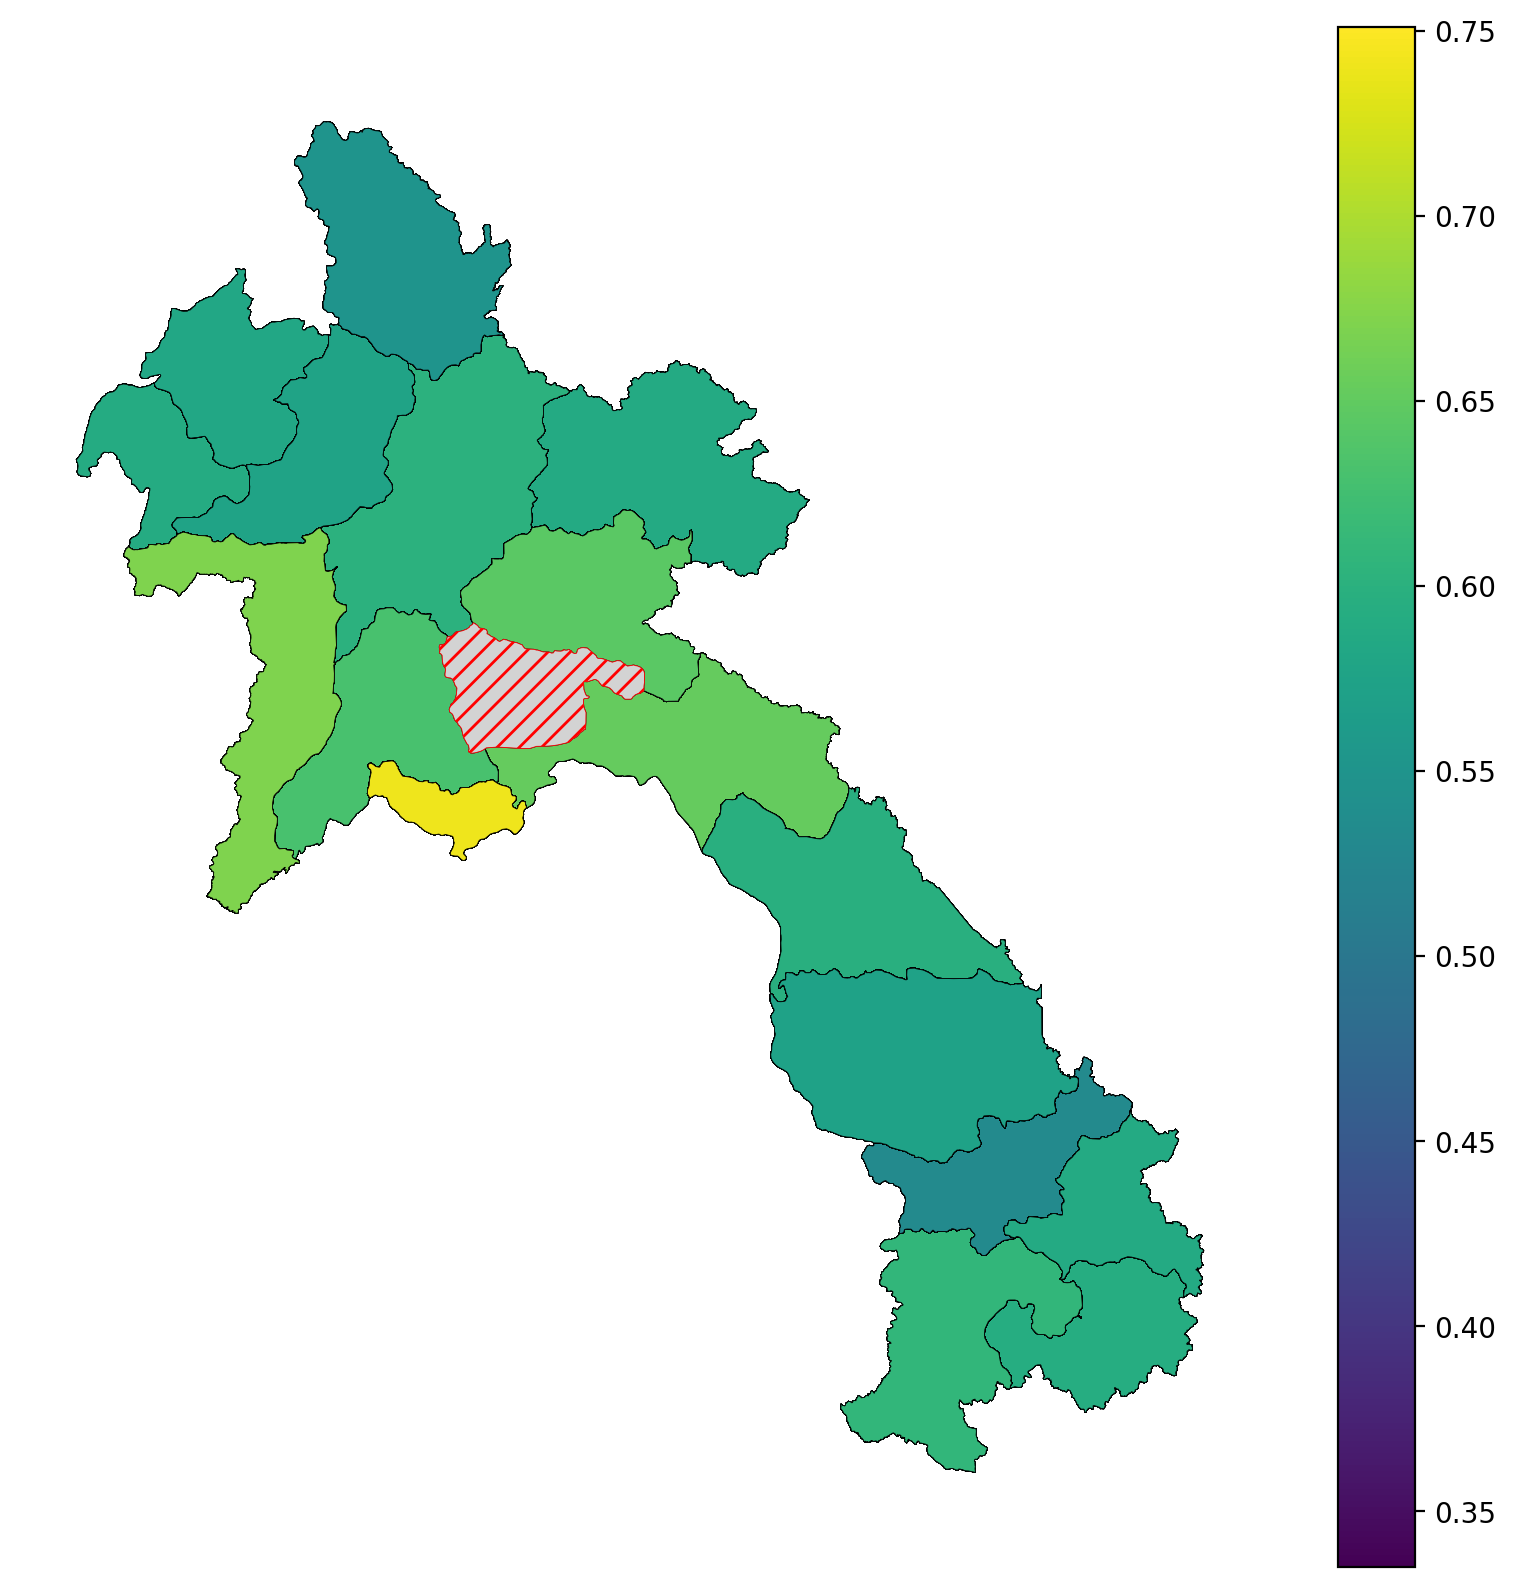

In [40]:
# Chloropleth Map of SHDI by province 
shdi_map = shdi_lvl1_merge.plot(
    column="shdi_value",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={
        "color": "lightgrey",
        "label": "No HDI data", 
        "edgecolor": "red",
        "hatch": "///"
    }
)
shdi_map.set_axis_off();

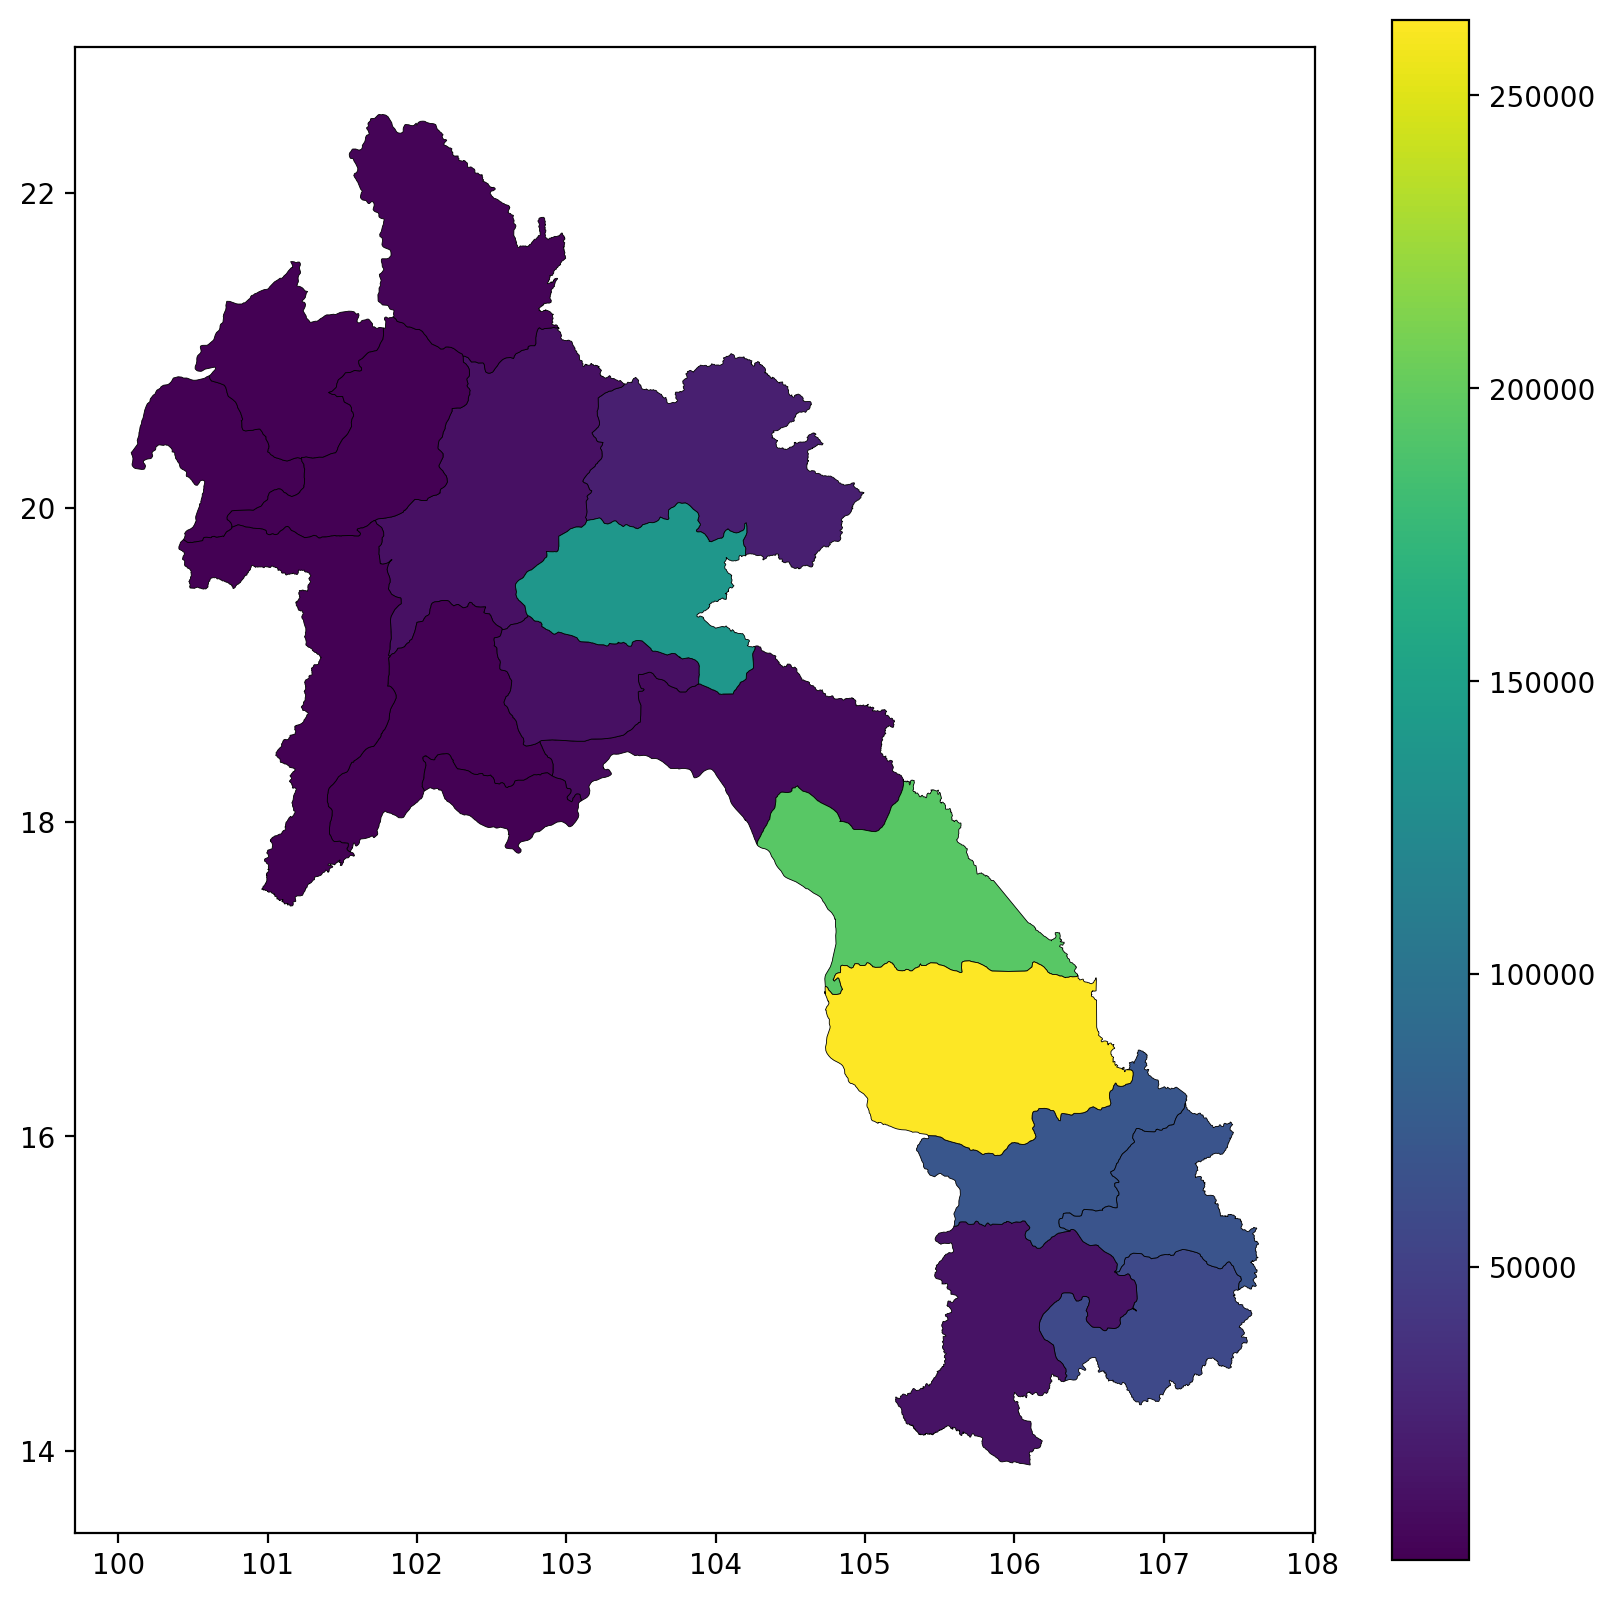

In [41]:
# Chloropleth Map of bombing by province (number of strikes)
strikes_map = bombing_admin_df.plot(
    column="total_missions",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3
)
shdi_map.set_axis_off();

# Leveling Up our Mapping Using Nighttime Lights Data

In [14]:
# setting file path shortcuts
#raster_path = '../data/VNL_npp_2025_global_vcmslcfg_v2_c202604011200.median_masked.dat.tif'
#src_raster = '../data/laos_nightlights_2025.tif'
#shapefile_path = '../data/LaosBoundaryLvl1.json'

In [17]:
# dissolving the individual provinces into one single solid outline of the country
laos_boundary = gdf_provinces.dissolve()
shapes = laos_boundary.geometry.values

In [16]:
# 3. Open the global raster (Lazy load - only reads metadata)
#with rasterio.open(raster_path) as src:
    
    # Check if coordinate systems match before clipping
 #   if src.crs != gdf_provinces.crs:
  #      print(f"Warning: CRS mismatch. Raster is {src.crs}, Shapefile is {gdf_provinces.crs}")
        # If they don't match, you'd convert the shapefile here, but VIIRS and WGS84 usually align.
    
    # 4. Mask/Clip the raster using the Laos geometry
    # crop=True shrinks the bounding box down to just Laos
   # out_image, out_transform = mask(src, shapes, crop=True)
    #out_meta = src.meta

    # 5. Update the metadata to reflect the new, tiny dimensions
    #out_meta.update({
     #   "driver": "GTiff",
      #  "height": out_image.shape[1],
       # "width": out_image.shape[2],
        #"transform": out_transform
    #})

    # 6. Save the new clipped file to your data folder
    #with rasterio.open(src_raster, "w", **out_meta) as dest:
     #   dest.write(out_image)

RasterioIOError: ../data/VNL_npp_2025_global_vcmslcfg_v2_c202604011200.median_masked.dat.tif: No such file or directory

Plotting the lights data

In [67]:
# 2. Load your clipped night-lights raster file
src_raster = rasterio.open('../data/laos_nightlights_2025.tif')

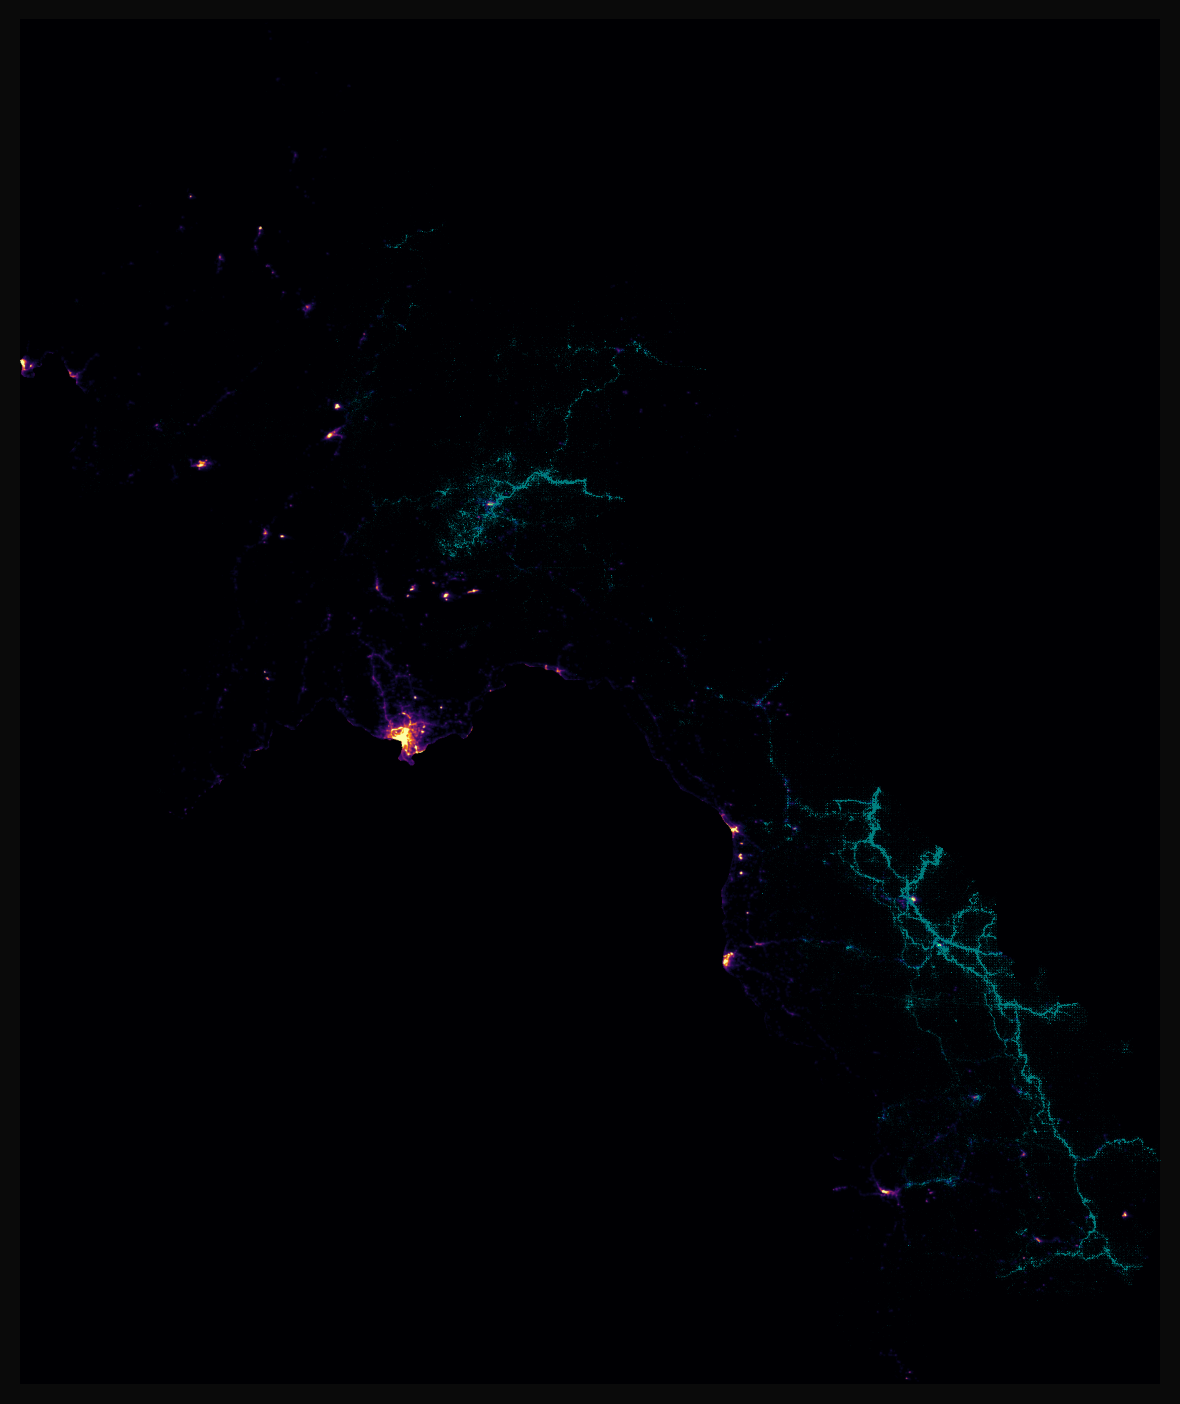

In [68]:
# Read band 1 into an array to calculate statistics
raster_array = src_raster.read(1)

# Fix 1: Calculate Contrast Stretching
# We find the 99th percentile of non-zero light values. 
# This ignores the absolute brightest outliers and brings out rural towns.
vmax_stretch = np.percentile(raster_array[raster_array > 0], 99)

# 2. Setup Canvas
fig, ax = plt.subplots(figsize=(6, 18), facecolor='#0a0a0a')
ax.set_facecolor('#0a0a0a')

# 3. Plot Raster with explicit scaling parameters
vmin=0 #forces unlit areas to pure black
vmax=vmax_stretch # forces everything above the 99th percentile to max brightness
_ = show(src_raster, ax=ax, cmap='inferno', vmin=0, vmax=vmax_stretch)

# Fix 2: Micro-scaling the Points
# - markersize is dropped to 0.02 (making them tiny pinpricks)
# - alpha is dropped to 0.008 (requiring hundreds of layers to saturate)
laos_strikes_gdf.plot(
    ax=ax, 
    color='#00ffff', 
    markersize=0.1, 
    alpha=0.01, 
    marker='o',
    linewidth=0       # Prevents marker borders from adding ghost opacity
)

# 4. Styling
#ax.set_title("Spatial Overlap: Historical Bombing Footprint vs. Modern Development (99th Percentile Contrast Stretch)", 
 #            color='white', fontsize=16, pad=20, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

src_raster.close()

<Axes: >

# Integrating District Boundaries

In [ ]:
# Loading district boundaries
gdf_districts = gpd.read_file('../data/LaosBoundaryLvl2.json')
print(gdf_districts.head())

# 3. Set up the plotting canvas
fig, ax = plt.subplots(figsize=(10, 10))

# 4. Plot the GeoDataFrame
# - facecolor: fills the polygons. 'whitesmoke' gives a nice base map feel.
# - edgecolor: color of the province borders.
# - linewidth: thickness of the borders.
gdf_districts.plot(
    ax=ax, 
    facecolor='whitesmoke', 
    edgecolor='black', 
    linewidth=0.8
)

# 5. Formatting the map
plt.title('Laos Administrative Boundaries', fontsize=16, pad=20)

# Turn off the latitude/longitude axis labels for a cleaner, map-like appearance
ax.axis('off')

# 6. Render the plot
plt.tight_layout()
plt.show()